Loading images...
Loaded 42 images
Running inference...
Inference complete! Detected cells in each image:
  20211222_094342_petiole_test_00100.tiff: 2045 cells
  20211222_094342_petiole_test_00200.tiff: 2202 cells
  20211222_094342_petiole_test_00300.tiff: 2241 cells
  20211222_094342_petiole_test_00400.tiff: 2324 cells
  20211222_094342_petiole_test_00500.tiff: 2291 cells
  20211222_104840_petiole_test2_00100.tiff: 2412 cells
  20211222_104840_petiole_test2_00200.tiff: 2601 cells
  20211222_104840_petiole_test2_00300.tiff: 2766 cells
  20211222_104840_petiole_test2_00400.tiff: 2856 cells
  20211222_104840_petiole_test2_00500.tiff: 2969 cells
  20211222_113313_petiole3_00100.tiff: 2376 cells
  20211222_113313_petiole3_00200.tiff: 2445 cells
  20211222_113313_petiole3_00300.tiff: 2581 cells
  20211222_113313_petiole3_00400.tiff: 2602 cells
  20211222_113313_petiole3_00500.tiff: 2793 cells
  20211222_125057_petiole4_00100.tiff: 2630 cells
  20211222_125057_petiole4_00200.tiff: 2729 cells

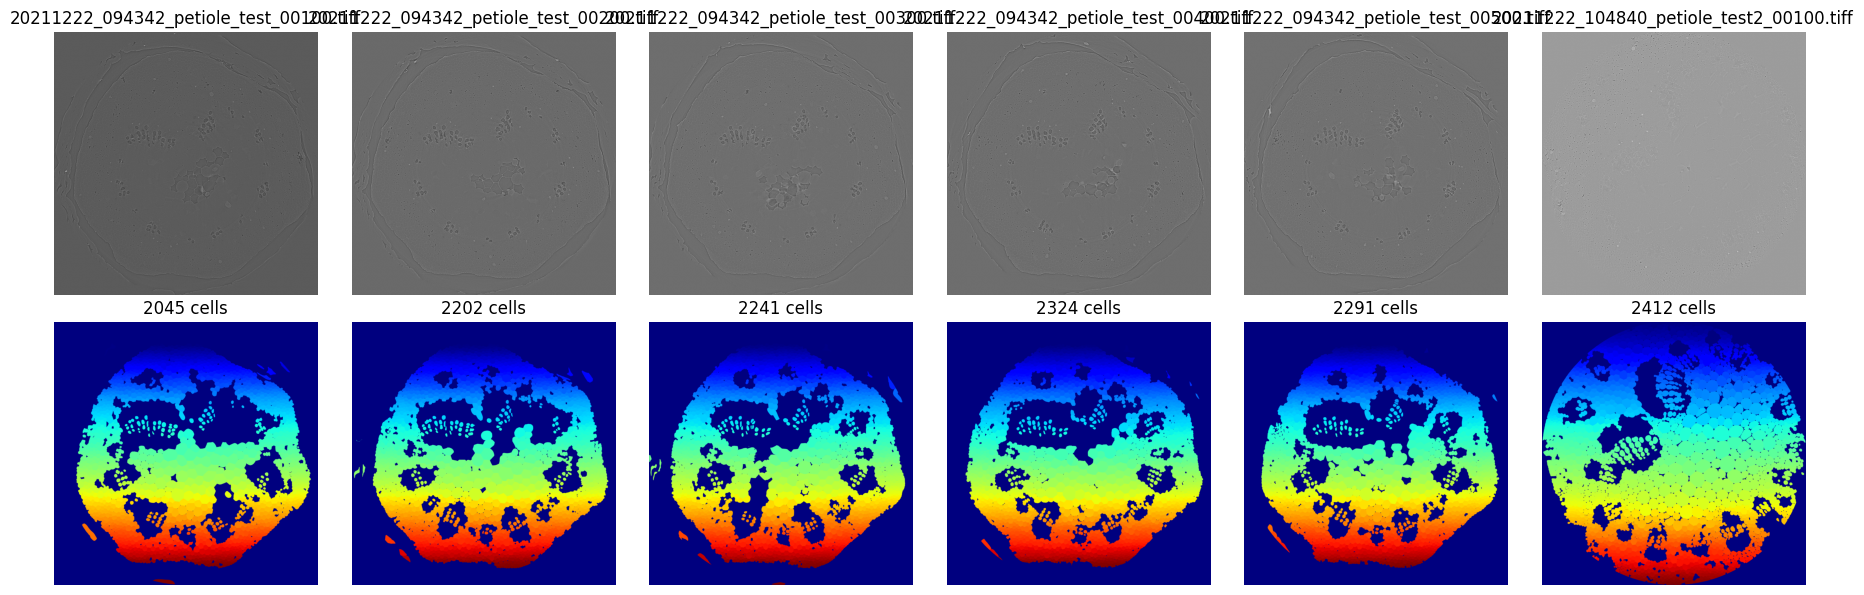

In [1]:
from cellpose import models
from glob import glob
from natsort import natsorted
import tifffile
import matplotlib.pyplot as plt
from pathlib import Path

# Define paths
image_dir = "/pscratch/sd/x/xchong/sam3_finetune/seg_annotation_pipeline2/data/images"
model_path = "/pscratch/sd/x/xchong/cellpose/models/petiole_model_flow0"  # Update this

# Load all TIFF files
print("Loading images...")
test_files = natsorted(glob(f"{image_dir}/*.tif") + glob(f"{image_dir}/*.tiff"))
test_files = [f for f in test_files if "_masks" not in f and "_flows" not in f]
test_data = [tifffile.imread(f) for f in test_files]

print(f"Loaded {len(test_data)} images")

# Load model and run inference
print("Running inference...")
model = models.CellposeModel(gpu=True, pretrained_model=model_path)
masks = model.eval(test_data, batch_size=32)[0]

print(f"Inference complete! Detected cells in each image:")
for i, (file, mask) in enumerate(zip(test_files, masks)):
    print(f"  {Path(file).name}: {mask.max()} cells")

# Plot first few results
n_show = min(6, len(test_data))
fig, axes = plt.subplots(2, n_show, figsize=(3*n_show, 6))

for i in range(n_show):
    axes[0, i].imshow(test_data[i], cmap='gray')
    axes[0, i].set_title(Path(test_files[i]).name)
    axes[0, i].axis('off')
    
    axes[1, i].imshow(masks[i], cmap='jet')
    axes[1, i].set_title(f'{masks[i].max()} cells')
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('inference_results.png', dpi=150, bbox_inches='tight')
plt.show()